In [26]:
!pip install transformers datasets peft evaluate accelerate

In [27]:
import time
import torch
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

In [28]:
dataset = load_dataset("imdb")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length")

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [29]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    print("Unique predictions:", set(preds))
    print("Unique labels:", set(labels))

    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels)["f1"],
    }

In [30]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [31]:
def train_model(model, output_dir):

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        logging_steps=100,
        fp16=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"].shuffle(seed=42),
        eval_dataset=dataset["test"].shuffle(seed=42),
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    end = time.time()

    results = trainer.evaluate()

    model_size = sum(p.numel() for p in model.parameters()) / 1e6

    return results, end - start, model_size

In [32]:
model_full = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

full_results, full_time, full_size = train_model(model_full, "./full")

print("FULL FT:", full_results, full_time, full_size)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.203845,0.231546,0.935960,0.935726
2,0.172800,0.262830,0.941760,0.942532


Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}
Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}


Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}
FULL FT: {'eval_loss': 0.26282960176467896, 'eval_accuracy': 0.94176, 'eval_f1': 0.942532365014209, 'eval_runtime': 200.7689, 'eval_samples_per_second': 124.521, 'eval_steps_per_second': 15.565, 'epoch': 2.0} 1844.9279794692993 109.483778


In [33]:
model_lora = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
)

model_lora = get_peft_model(model_lora, lora_config)

lora_results, lora_time, lora_size = train_model(model_lora, "./lora")

print("LoRA:", lora_results, lora_time, lora_size)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.220654,0.284534,0.899120,0.899490
2,0.297573,0.273458,0.902600,0.903751


Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}
Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}


Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}
LoRA: {'eval_loss': 0.2734576165676117, 'eval_accuracy': 0.9026, 'eval_f1': 0.9037511364085536, 'eval_runtime': 221.2909, 'eval_samples_per_second': 112.973, 'eval_steps_per_second': 14.122, 'epoch': 2.0} 1592.5327594280243 109.780228


In [34]:
from peft import PromptTuningConfig

model_adapter = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

adapter_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
)

model_adapter = get_peft_model(model_adapter, adapter_config)

adapter_results, adapter_time, adapter_size = train_model(model_adapter, "./adapter")

print("ADAPTER:", adapter_results, adapter_time, adapter_size)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.256108,0.300093,0.887960,0.887061
2,0.314733,0.288288,0.895160,0.896350


Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}
Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}


Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}
ADAPTER: {'eval_loss': 0.288287878036499, 'eval_accuracy': 0.89516, 'eval_f1': 0.8963499031122711, 'eval_runtime': 223.0117, 'eval_samples_per_second': 112.102, 'eval_steps_per_second': 14.013, 'epoch': 2.0} 1595.027314901352 109.632772


In [35]:
model_freeze = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

for name, param in model_freeze.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

freeze_results, freeze_time, freeze_size = train_model(model_freeze, "./freeze")

print("FREEZE:", freeze_results, freeze_time, freeze_size)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.661260,0.655147,0.646000,0.706798
2,0.650582,0.645999,0.663720,0.715335


Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}
Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}


Unique predictions: {np.int64(0), np.int64(1)}
Unique labels: {np.int64(0), np.int64(1)}
FREEZE: {'eval_loss': 0.6459990739822388, 'eval_accuracy': 0.66372, 'eval_f1': 0.7153353875325906, 'eval_runtime': 199.4824, 'eval_samples_per_second': 125.324, 'eval_steps_per_second': 15.666, 'epoch': 2.0} 866.3975884914398 109.483778


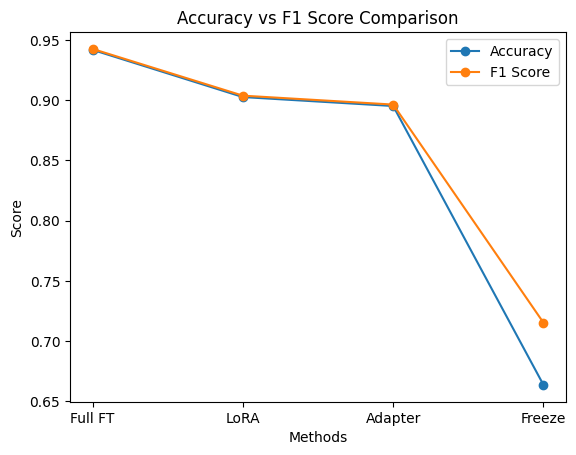

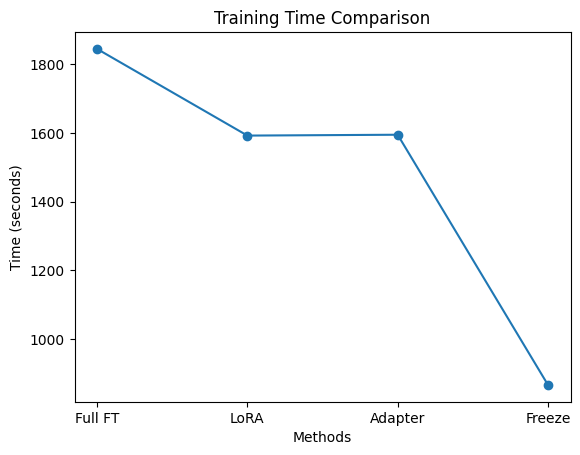

In [36]:
import matplotlib.pyplot as plt

methods = ["Full FT", "LoRA", "Adapter", "Freeze"]

accuracy = [full_results['eval_accuracy'], lora_results['eval_accuracy'], adapter_results['eval_accuracy'], freeze_results['eval_accuracy']]
f1_score = [full_results['eval_f1'], lora_results['eval_f1'], adapter_results['eval_f1'], freeze_results['eval_f1']]
training_time = [full_time, lora_time, adapter_time, freeze_time]

# Accuracy & F1 plot
plt.figure()
plt.plot(methods, accuracy, marker='o', label='Accuracy')
plt.plot(methods, f1_score, marker='o', label='F1 Score')
plt.xlabel("Methods")
plt.ylabel("Score")
plt.title("Accuracy vs F1 Score Comparison")
plt.legend()
plt.show()

# Training time plot
plt.figure()
plt.plot(methods, training_time, marker='o')
plt.xlabel("Methods")
plt.ylabel("Time (seconds)")
plt.title("Training Time Comparison")
plt.show()